# RAC feature completeness analysis

Quantifies the mofdscribe linker-RAC computation failure (28.5% of MOFs lack >=1 linker-centred RAC) and checks whether the affected structures are systematically different by topology and metal node. Produces the appendix figure.

Inputs:
- rac_features.parquet
- `data/merged/hmof_merged.parquet

Output:
- results/rac-completeness/rac_linker_missingness.png

Environment:
Runs in the core analysis environment (Python 3.11). Key packages: pandas, numpy, matplotlib, pyarrow.

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = pathlib.Path('..').resolve()
RAC_PARQUET = ROOT / 'rac_features.parquet'
MERGED      = ROOT / 'data' / 'merged' / 'hmof_merged.parquet'
OUTDIR      = ROOT / 'results' / 'rac-completeness'
OUTDIR.mkdir(parents=True, exist_ok=True)

# Colours / style matched to the existing distribution figures
FULL = '#6b9bc3'   # full dataset (blue)
MISS = '#ff826c'   # affected subset (salmon)
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

In [2]:
# Load RAC features and flag MOFs missing >=1 linker-centred RAC
rac = pd.read_parquet(RAC_PARQUET)
linker_cols = [c for c in rac.columns if c.startswith('racs_bb-linker')]
node_cols   = [c for c in rac.columns if c.startswith('racs_bb-nodes')]

flag = pd.DataFrame({
    'name': rac['name'],
    'miss_link': rac[linker_cols].isna().any(axis=1),
    'miss_node': rac[node_cols].isna().any(axis=1),
})

n = len(flag)
print(f'MOFs total:                {n:,}')
print(f'Linker RAC columns:        {len(linker_cols)}')
print(f'Node RAC columns:          {len(node_cols)}')
print(f'Missing >=1 linker RAC:    {flag.miss_link.sum():,} ({flag.miss_link.mean()*100:.1f}%)')
print(f'Missing >=1 node RAC:      {flag.miss_node.sum():,} ({flag.miss_node.mean()*100:.1f}%)')

MOFs total:                111,469
Linker RAC columns:        384
Node RAC columns:          96
Missing >=1 linker RAC:    31,743 (28.5%)
Missing >=1 node RAC:      5 (0.0%)


In [3]:
# Join structural metadata and inspect whether missingness is systematic
meta = pd.read_parquet(MERGED, columns=['name', 'topology', 'metal_node'])
j = flag.merge(meta, on='name', how='inner')

for col in ['topology', 'metal_node']:
    g = (j.groupby(col)
           .agg(n=('miss_link', 'size'), miss_pct=('miss_link', lambda s: s.mean()*100))
           .sort_values('n', ascending=False).head(8))
    print(f'\n=== linker-RAC missing rate by {col} (top 8 by count) ===')
    print(g.round(1).to_string())


=== linker-RAC missing rate by topology (top 8 by count) ===
               n  miss_pct
topology                  
pcu       100462      27.8
rna         5369      39.1
dia         1567      16.5
sql         1139      54.2
tbo          850      28.1
hex          783      21.3
fcu          449      27.4
nbo          219      24.7

=== linker-RAC missing rate by metal_node (top 8 by count) ===
                n  miss_pct
metal_node                 
Zn          69039      26.9
Cu          29175      31.4
V            5320      39.7
sql          3277      23.2
Zr           3085      19.3
ERROR         716      35.3
UNKNOWN       677      34.4
pcu            60      41.7


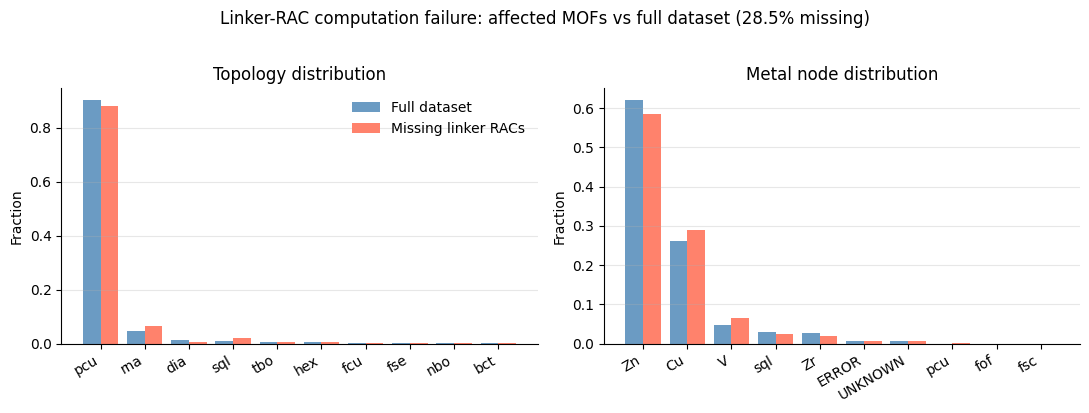

In [4]:
# Appendix figure: distribution of affected MOFs vs full dataset
miss = j[j.miss_link]

def dist(col, topn=10):
    full = j[col].value_counts(normalize=True)
    sub  = miss[col].value_counts(normalize=True)
    order = full.head(topn).index
    return order, full.reindex(order, fill_value=0), sub.reindex(order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (col, title) in zip(axes, [('topology', 'Topology'), ('metal_node', 'Metal node')]):
    order, full, sub = dist(col)
    x = np.arange(len(order)); w = 0.4
    ax.bar(x - w/2, full.values, w, color=FULL, label='Full dataset')
    ax.bar(x + w/2, sub.values,  w, color=MISS, label='Missing linker RACs')
    ax.set_xticks(x); ax.set_xticklabels(order, rotation=30, ha='right')
    ax.set_ylabel('Fraction'); ax.set_title(f'{title} distribution'); ax.grid(axis='y', alpha=.3)
axes[0].legend(frameon=False)
fig.suptitle('Linker-RAC computation failure: affected MOFs vs full dataset (28.5% missing)', y=1.02)
fig.tight_layout()
fig.savefig(OUTDIR / 'rac_linker_missingness.png', dpi=200, bbox_inches='tight')
plt.show()